In [13]:
import json

def get_metric_value(file_name, dataset_name):
    try:
        with open(file_name, 'r') as file:
            data = json.load(file)[dataset_name]
    except FileNotFoundError:
        return 0
        
    keys = list(data.keys())  
    metric = keys[1]
    value = data[metric]
    
    return value
 
def get_results(model_name):  
    
    datasets = ["squadv2", "mlqa_en_en", "wmt16-de-en", "wmt16-ro-en", "xsum", "cnn_dailymail"]
    methods = [
        {"folder": "partinfer_results", "filename": f"partinfer_{model_name}.json", "name": "partinfer"},
        {"folder": "coreinfer_results", "filename": f"coreinfer_{model_name}.json", "name": "coreinfer"},
        {"folder": "coreinfer_results", "filename": f"coreinfer_partial_loading_{model_name}.json", "name": "coreinfer_default_partial"},
        {"folder": "coreinfer_results", "filename": f"coreinfer_random_loading_{model_name}.json", "name": "coreinfer_random_partial"},
        {"folder": "dense_results", "filename": f"dense_{model_name}.json", "name": "dense"},
        {"folder": "dense_results", "filename": f"quantized_{model_name}-4bit.json", "name": "quantized"},
    ]

    results = {}
    for dataset in datasets:
        for method in methods:
            folder = method["folder"]
            filename = method["filename"]
            name = method["name"]
            file_name = f"{folder}/{dataset}/{filename}"
            value = get_metric_value(file_name, dataset)
            
            if dataset not in results:
                results[dataset] = {}
                
            results[dataset][name] = value
    
    return results

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def draw_graphs(model_name):
    results = get_results(model_name)
    print(f"Results for model: {model_name}")
    print(results)

    # Group datasets into two subplots
    subplot1 = ["squadv2", "wmt16-de-en", "wmt16-ro-en"]
    subplot2 = ["mlqa_en_en", "xsum", "cnn_dailymail"]

    graphs = [
        ["partinfer", "coreinfer", "coreinfer_default_partial", "coreinfer_random_partial"],
        ["dense", "quantized"],
    ]

    method_labels = {
        "partinfer": "PartInfer",
        "coreinfer": "CoreInfer",
        "partinfer_modified": "PartInfer Modified",
        "coreinfer_default_partial": "CoreInfer + Our Partial Loading",
        "coreinfer_random_partial": "CoreInfer + Random Partial Loading",
        "reference": "Reference",
        "dense": "Dense 70%",
        "quantized": "Quantized",
    }

    labels = {
        "squadv2": "SQuADv2\n(Exact Match)",
        "mlqa_en_en": "MLQA\n(Exact Match)",
        "wmt16-de-en": "WMT16 DE-EN\n(BLEU)",
        "wmt16-ro-en": "WMT16 RO-EN\n(BLEU)",
        "xsum": "XSum\n(Rouge)",
        "cnn_dailymail": "CNN/DailyMail\n(Rouge)"
    }

    for graph in graphs:

        # Filter the results to only the relevant methods
        included_results = {}
        for dataset, metrics in results.items():
            included_results[dataset] = {}
            for method, value in metrics.items():
                if method in graph:
                    included_results[dataset][method] = value

        method_names = list(next(iter(included_results.values())).keys())
        bar_width = 0.175

        # ------------------------------------------
        #         CREATE FIGURE WITH 2 SUBPLOTS
        # ------------------------------------------
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

        # ------------------------------------------
        # Subplot 1 (3 datasets)
        # ------------------------------------------
        x1 = subplot1
        r1 = np.arange(len(x1))

        ax1 = axes[0]
        for i, method in enumerate(method_names):
            y = [included_results[ds][method] for ds in x1]
            xpos = r1 + i * bar_width
            bars = ax1.bar(xpos, y, bar_width, label=method_labels[method])

            # Add value labels
            for bar in bars:
                height = bar.get_height()
                ax1.annotate(
                    f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom",
                    fontsize=10
                )

        ax1.set_xticks(r1 + bar_width * (len(method_names)-1)/2)
        ax1.set_xticklabels([labels[d] for d in x1], fontsize=13)
        ax1.set_ylabel("Metric Value", fontsize=14)
        ax1.tick_params(axis='y', labelsize=12)

        # Increase y-limit by 10% for subplot 1
        max_y1 = max(included_results[ds][m] for ds in x1 for m in method_names)
        ax1.set_ylim(0, max_y1 * 1.1)

        # ------------------------------------------
        # Subplot 2 (3 datasets)
        # ------------------------------------------
        x2 = subplot2
        r2 = np.arange(len(x2))

        ax2 = axes[1]
        for i, method in enumerate(method_names):
            y = [included_results[ds][method] for ds in x2]
            xpos = r2 + i * bar_width
            bars = ax2.bar(xpos, y, bar_width)

            # Add value labels
            for bar in bars:
                height = bar.get_height()
                ax2.annotate(
                    f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom",
                    fontsize=10
                )

        ax2.set_xticks(r2 + bar_width * (len(method_names)-1)/2)
        ax2.set_xticklabels([labels[d] for d in x2], fontsize=13)
        ax2.tick_params(axis='y', labelsize=12)

        # Increase y-limit by 10% for subplot 2
        max_y2 = max(included_results[ds][m] for ds in x2 for m in method_names)
        ax2.set_ylim(0, max_y2 * 1.1)

        # ------------------------------------------
        # Shared Legend
        # ------------------------------------------
        # if model_name == "llama3-3b":
        handles, legend_labels = ax1.get_legend_handles_labels()
        fig.legend(handles, legend_labels, fontsize=12, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.08))

        # ------------------------------------------
        # Shared X Label
        # ------------------------------------------
        # if model_name == "llama3-1b":
        fig.text(0.5, 0.02, "Datasets (Metric Type)", ha="center", fontsize=14)

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()


Results for model: llama3-1b
{'squadv2': {'partinfer': 13.745472921755242, 'coreinfer': 5.996799460961846, 'coreinfer_default_partial': 3.8490693169375896, 'coreinfer_random_partial': 1.263370672955445, 'dense': 17.87248378674303, 'quantized': 13.972879642887223}, 'mlqa_en_en': {'partinfer': 0.4003451251078516, 'coreinfer': 0.35056082830025886, 'coreinfer_default_partial': 0.27739430543572047, 'coreinfer_random_partial': 0.0005176876617773944, 'dense': 0.4358067299396031, 'quantized': 0.4270923209663503}, 'wmt16-de-en': {'partinfer': 10.500410855194765, 'coreinfer': 2.9080679602053645, 'coreinfer_default_partial': 1.6805202725052915, 'coreinfer_random_partial': 0.02730951070095959, 'dense': 27.33849332466955, 'quantized': 26.703915239052332}, 'wmt16-ro-en': {'partinfer': 10.853763064747437, 'coreinfer': 2.8688824672862685, 'coreinfer_default_partial': 1.393195318978119, 'coreinfer_random_partial': 0.03493754860443225, 'dense': 25.948330218238098, 'quantized': 24.64966094800904}, 'xsum'

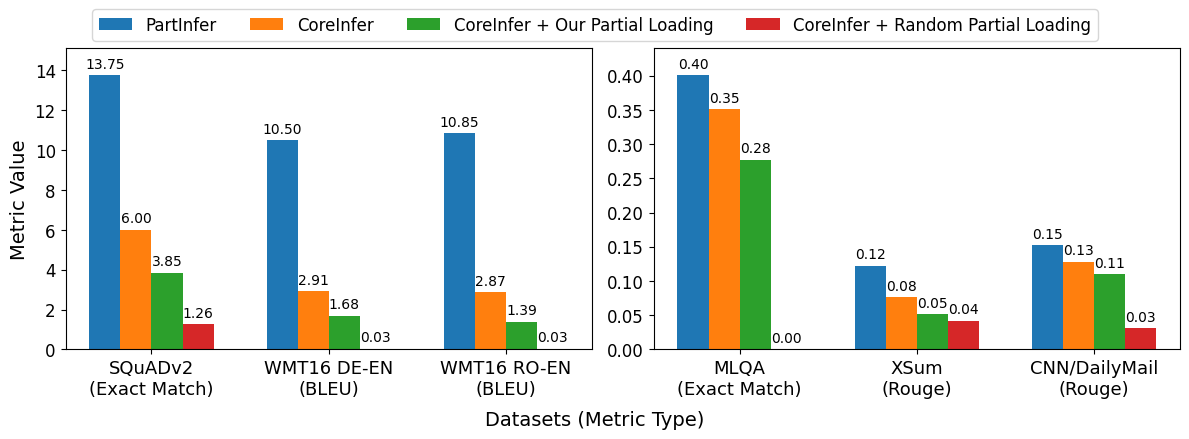

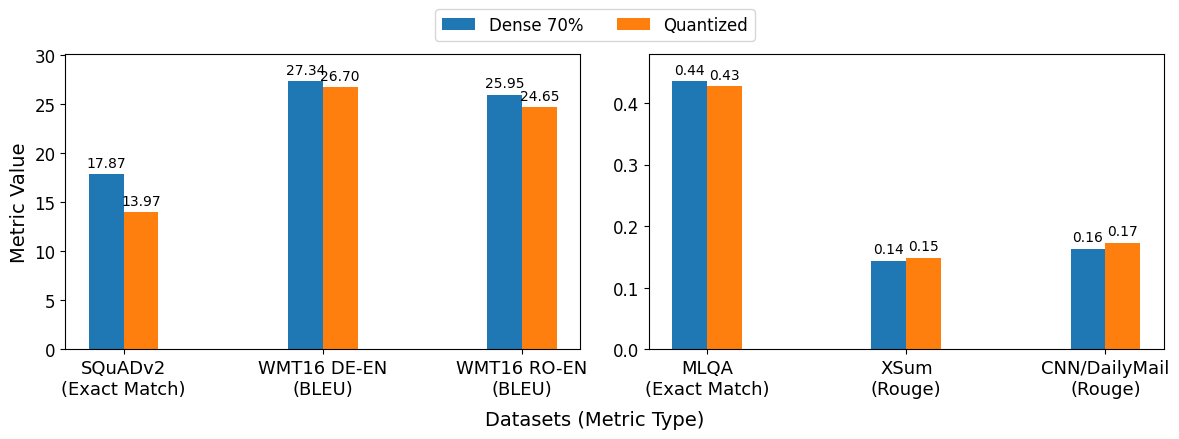

Results for model: llama3-3b
{'squadv2': {'partinfer': 22.546955276678176, 'coreinfer': 17.367135517560854, 'coreinfer_default_partial': 11.597742777730986, 'coreinfer_random_partial': 0.26109660574412535, 'dense': 26.41286953592184, 'quantized': 30.135601785563885}, 'mlqa_en_en': {'partinfer': 0.5182053494391717, 'coreinfer': 0.5255392579810181, 'coreinfer_default_partial': 0.44012079378774804, 'coreinfer_random_partial': 0.012338222605694565, 'dense': 0.5455565142364107, 'quantized': 0.5949956859361518}, 'wmt16-de-en': {'partinfer': 25.67675801159195, 'coreinfer': 4.970304889976711, 'coreinfer_default_partial': 1.6960038985190826, 'coreinfer_random_partial': 0.040262468808555885, 'dense': 34.905828995593275, 'quantized': 37.64284326233865}, 'wmt16-ro-en': {'partinfer': 25.964556102484494, 'coreinfer': 4.975459864913002, 'coreinfer_default_partial': 1.6460510031400775, 'coreinfer_random_partial': 0.02910995885066446, 'dense': 33.401664486185325, 'quantized': 35.02644102386154}, 'xsum'

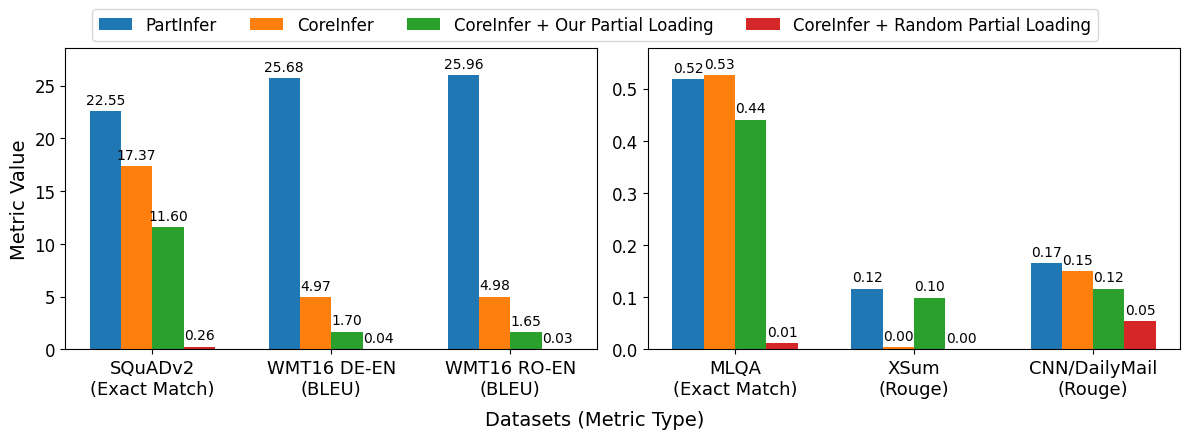

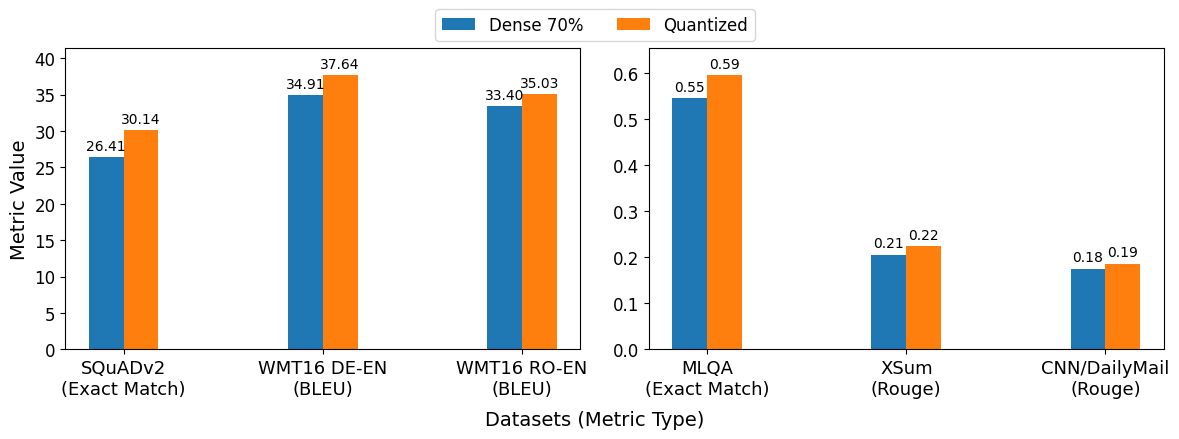

Results for model: qwen2.5-3b
{'squadv2': {'partinfer': 24.324096689968837, 'coreinfer': 32.57811841994441, 'coreinfer_default_partial': 35.68601027541481, 'coreinfer_random_partial': 29.64709845868778, 'dense': 31.062073612397878, 'quantized': 34.32156994862292}, 'mlqa_en_en': {'partinfer': 0.5328731665228645, 'coreinfer': 0.5260569456427955, 'coreinfer_default_partial': 0.4797238999137187, 'coreinfer_random_partial': 0.342709232096635, 'dense': 0.5767040552200172, 'quantized': 0.589732528041415}, 'wmt16-de-en': {'partinfer': 8.277559765657696, 'coreinfer': 4.315626807932374, 'coreinfer_default_partial': 1.5533067905883609, 'coreinfer_random_partial': 0.4432552467026756, 'dense': 27.96800708492552, 'quantized': 18.184643772401497}, 'wmt16-ro-en': {'partinfer': 4.829772969128065, 'coreinfer': 4.087997764317, 'coreinfer_default_partial': 0.7983989844817612, 'coreinfer_random_partial': 0.1622671762402542, 'dense': 20.286316438909832, 'quantized': 11.295675365350785}, 'xsum': {'partinfer'

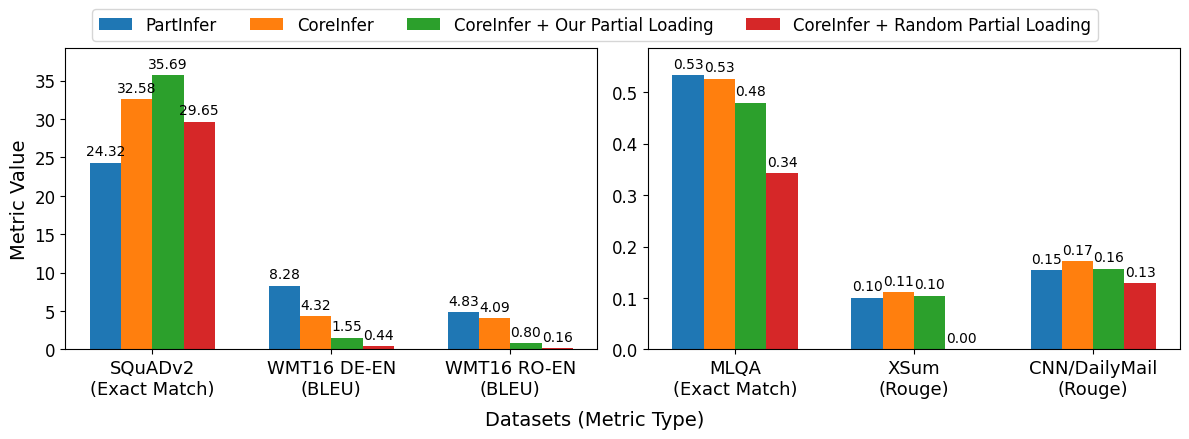

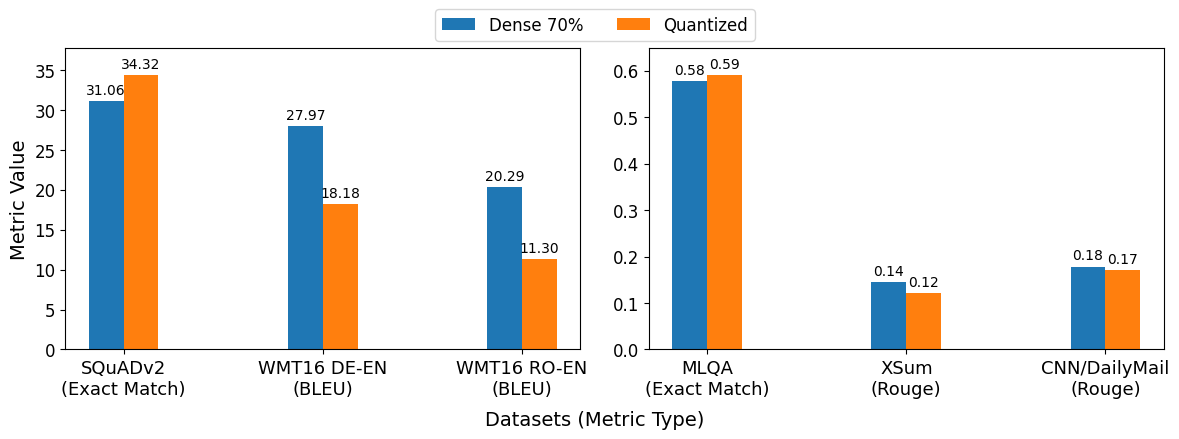

In [23]:
for model in ["llama3-1b", "llama3-3b", "qwen2.5-3b"]:
    draw_graphs(model)

# Analyze SpeedUp

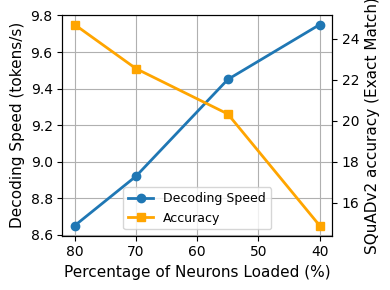

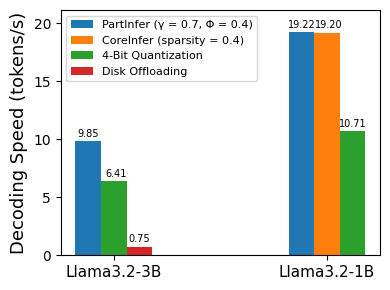

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# ---------------- Graph Data ----------------
loading_perc = [80, 70, 55, 40]
throughput_loading = [8.65, 8.92, 9.45, 9.75]   # speed
accuracy_loading = [24.70, 22.55, 20.33, 14.87] # example accuracy values

fig, ax1 = plt.subplots(figsize=(4,3))

# First line (speed)
ax1.plot(loading_perc, throughput_loading, marker='o', linewidth=2, label="Decoding Speed")
ax1.set_xlabel("Percentage of Neurons Loaded (%)", fontsize=11)
ax1.set_ylabel("Decoding Speed (tokens/s)", fontsize=11)
ax1.invert_xaxis()
ax1.grid(True)

# Second Y-axis (accuracy)
ax2 = ax1.twinx()
ax2.plot(loading_perc, accuracy_loading, marker='s', linewidth=2, color='orange', label="Accuracy")
ax2.set_ylabel("SQuADv2 accuracy (Exact Match)", fontsize=11)

# Optional: combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc="lower center", fontsize=9)

plt.tight_layout()
plt.show()

# ---------------- Graph 2: Partial Computation ----------------
methods = ["PartInfer (γ = 0.7, Φ = 0.4)", "CoreInfer (sparsity = 0.4)", "4-Bit Quantization", "Disk Offloading"]

throughput_values = {
    "Llama3.2-3B": [9.85, None, 6.41, 0.75],
    "Llama3.2-1B": [19.22, 19.20, 10.71, None]
}

models = list(throughput_values.keys())
n_models = len(models)
n_methods = len(methods)

bar_width = 0.12
x = np.arange(n_models)

# --- Custom colors ---
colors = [
    "#1f77b4",  # from user
    "#ff7f0e",  # from user
    "#2ca02c",  # from user
    "#d62728",  # extra
    "#9467bd"   # extra
]

patches = []

plt.figure(figsize=(4, 3))

for j, model in enumerate(models):

    # Values for this model
    vals = throughput_values[model]

    # Valid bars (methods that have values)
    valid_methods = [(i, vals[i]) for i in range(n_methods) if vals[i] is not None]
    k = len(valid_methods)  # number of bars that actually exist

    # Compute centered offsets only for valid bars
    for idx, (method_index, val) in enumerate(valid_methods):
        color = colors[method_index]

        # Center the bars according to how many exist (k)
        offset = x[j] + (idx - (k - 1)/2) * bar_width

        # Draw bar
        plt.bar(offset, val, bar_width, color=color)

        # Add label
        if idx == 1:
            offset += 0.01
        plt.text(offset, val + 0.2, f"{val:.2f}",
                 ha='center', va='bottom', fontsize=7)

# Create legend from colors/methods
patches = [Patch(facecolor=colors[i], label=methods[i]) for i in range(n_methods)]

plt.xticks(x, models, fontsize=11)
plt.ylabel("Decoding Speed (tokens/s)", fontsize=13)

# Increase y-limit slightly based on plotted values (ignore None)
all_vals = [v for vals_list in throughput_values.values() for v in vals_list if v is not None]
if all_vals:
    y_max = max(all_vals)
    plt.ylim(0, y_max * 1.1)  # increase top by 15%

# Legend top-left, single column
plt.legend(handles=patches, fontsize=8, loc="upper left", ncol=1)

plt.tight_layout()
plt.show()


## Ablation Studies

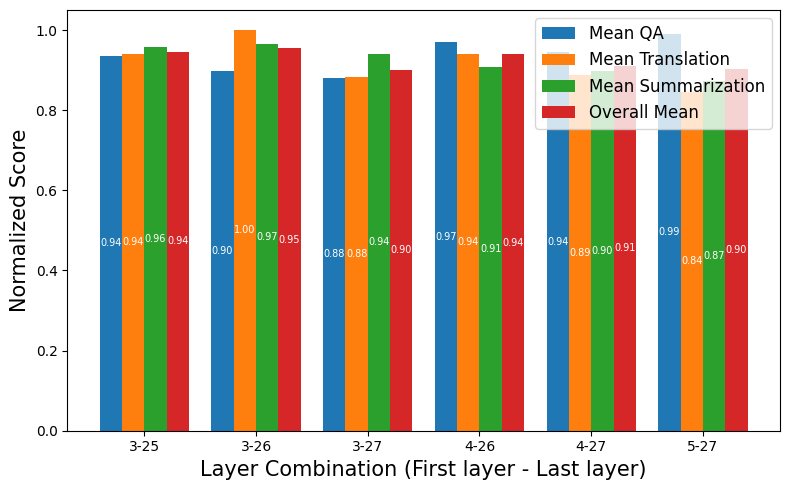

In [4]:
# Raw data (converted to Python floats)
data = {
    "3-25": [0.18, 24, 20.68, 25.41, 0.1046, 0.1078],
    "3-26": [0.168, 23.6, 21.63, 27.47, 0.114, 0.1004],
    "3-27": [0.168, 22.8, 19.51, 23.73, 0.1074, 0.101],
    "4-26": [0.184, 25.2, 19.51, 26.93, 0.1096, 0.0921],
    "4-27": [0.196, 22.4, 19.61, 23.91, 0.1095, 0.0901],
    "5-27": [0.192, 25.2, 18.51, 22.91, 0.1103, 0.0838],
}

layer_names = list(data.keys())

# Convert to array for normalization
values = np.array(list(data.values()))  # shape: (6 combinations, 6 tasks)

# Compute max per task (column)
task_max = values.max(axis=0)

# Normalize
normalized_values = values / task_max

# Prepare metric arrays
mean_qa = []
mean_translation = []
mean_summarization = []
mean_overall = []

for row in normalized_values:
    qa = np.mean(row[0:2])               # TriviaQA + SQuADv2
    translation = np.mean(row[2:4])      # WMT RO + WMT DE
    summarization = np.mean(row[4:6])    # XSum + CNN/DM
    overall = np.mean(row)               # All 6 tasks

    mean_qa.append(qa)
    mean_translation.append(translation)
    mean_summarization.append(summarization)
    mean_overall.append(overall)

# Plotting
x = np.arange(len(layer_names))
width = 0.2

plt.figure(figsize=(8, 5))

b1 = plt.bar(x - 1.5*width, mean_qa, width, label="Mean QA")
b2 = plt.bar(x - 0.5*width, mean_translation, width, label="Mean Translation")
b3 = plt.bar(x + 0.5*width, mean_summarization, width, label="Mean Summarization")
b4 = plt.bar(x + 1.5*width, mean_overall, width, label="Overall Mean")

# Write the value of each bar in the middle of it
for bar_container in (b1, b2, b3, b4):
    for bar in bar_container:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,                     # middle of the bar vertically
            f"{height:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if height > 0.5 else "black"  # contrast
        )

# Increase tick label font sizes for both axes
plt.xticks(x, layer_names, fontsize=10)
plt.tick_params(axis='y', labelsize=10)

plt.ylabel("Normalized Score", fontsize=15)
plt.xlabel("Layer Combination (First layer - Last layer)", fontsize=15)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


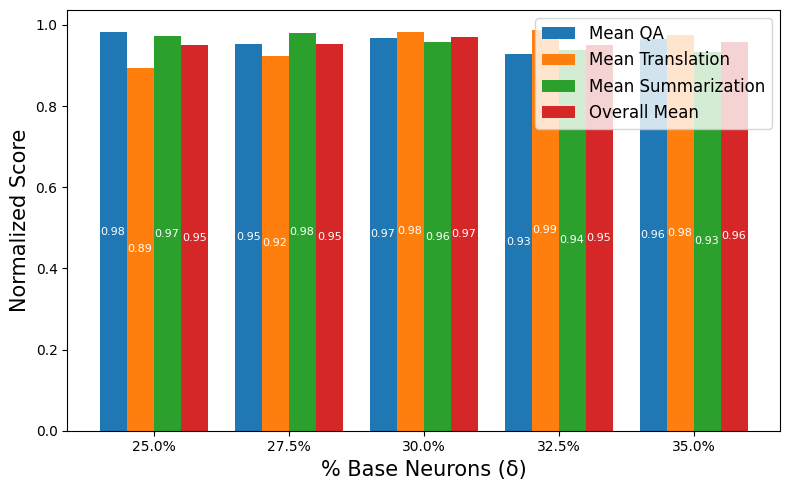

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data (converted to Python floats)
# NOTE: First column is % of base neurons → used only as label, not part of metrics
data = {
    "25.0%": [0.2, 21.2, 18.03, 24.1, 0.107, 0.09324],
    "27.5%": [0.196, 20.4, 19.09, 24.29, 0.1134, 0.08966],
    "30.0%": [0.198, 20.8, 20.38, 25.73, 0.1078, 0.08984],
    "32.5%": [0.188, 20.2, 19.87, 26.63, 0.1083, 0.08592],
    "35.0%": [0.186, 22.0, 19.88, 26.0, 0.1096, 0.084]
}

labels = list(data.keys())

# Extract values into array shape (7 combos, 6 tasks)
values = np.array(list(data.values()))

# Normalize each column by task max
task_max = values.max(axis=0)
normalized_values = values / task_max

# Compute mean metrics
mean_qa = []
mean_translation = []
mean_summarization = []
mean_overall = []

for row in normalized_values:
    qa = np.mean(row[0:2])               # Trivia + Squad
    translation = np.mean(row[2:4])      # RO + DE
    summarization = np.mean(row[4:6])    # XSum + CNN
    overall = np.mean(row)               # All 6 tasks

    mean_qa.append(qa)
    mean_translation.append(translation)
    mean_summarization.append(summarization)
    mean_overall.append(overall)

# Plot
x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(8, 5))

b1 = plt.bar(x - 1.5*width, mean_qa, width, label="Mean QA")
b2 = plt.bar(x - 0.5*width, mean_translation, width, label="Mean Translation")
b3 = plt.bar(x + 0.5*width, mean_summarization, width, label="Mean Summarization")
b4 = plt.bar(x + 1.5*width, mean_overall, width, label="Overall Mean")

# Write the value of each bar in the middle of it
for bar_container in (b1, b2, b3, b4):
    for bar in bar_container:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,                     # middle of the bar vertically
            f"{height:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if height > 0.5 else "black"  # contrast
        )

plt.xticks(x, labels, fontsize=10)
plt.tick_params(axis='y', labelsize=10)

plt.ylabel("Normalized Score", fontsize=15)
plt.xlabel("% Base Neurons (δ)", fontsize=15)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


# Peak Memory Usage

In [21]:
mem_stats = {
    "llama3-3b": {
        "reference": 6880.0,
        "partinfer": 5972.9,
        "coreinfer": 7444.2,
        "quantized": 3038.9
    },
    "llama3-1b": {
        "reference": 2860.1,
        "partinfer": 2600.4,
        "coreinfer": 2860.1,
        "quantized": 1526.2
    },
    "qwen2.5-3b": {
        "reference": 6480.0,
        "partinfer": 5377.8,
        "coreinfer": 7529.4,
        "quantized": 2677
    }
}